## Prompt

> Calculate LogP of vorasidenib. Then search all databases for its closest analogues using shape as the main metrics. Look only for lower LogP analogues. Then calculate UMAP using LogP as the main metric. Cluster all molecules using LogP.

### Step 1 — vorasidenib's structure and starting logP

Vorasidenib's SMILES was pulled from PubChem (`CanonicalSMILES` for the compound named `vorasidenib`) rather than typed from memory, and cross-checked against its known molecular formula (C14H13ClF6N6) before use.

In [1]:
from rdkit import Chem
from rdkit.Chem import Crippen, rdMolDescriptors

VORASIDENIB = "CC(C(F)(F)F)NC1=NC(=NC(=N1)C2=NC(=CC=C2)Cl)NC(C)C(F)(F)F"

starting_mol = Chem.MolFromSmiles(VORASIDENIB)
assert rdMolDescriptors.CalcMolFormula(starting_mol) == "C14H13ClF6N6"
starting_logp = Crippen.MolLogP(starting_mol)
print(f"Vorasidenib logP (RDKit Crippen): {starting_logp:.3f}")

Vorasidenib logP (RDKit Crippen): 4.312


### Step 2 — closest shape analogues across every database, filtered to lower logP

"Search all databases" means every database in the catalog, not one — looped over `dmc.catalog()["libraries"]` rather than a hardcoded list, and confirmed live first that every one of them supports `method="shape"` (`capabilities.search_cheese` includes `'shape'` for all 7). Duplicate molecules found in more than one database keep only their first occurrence.

In [2]:
from deepmedchem import Client
from rdkit.Chem import Descriptors

LIMIT = 200

with Client() as client:
    databases = [lib["database_id"] for lib in client.catalog()["libraries"]]
    rows = []
    seen_smiles = set()
    for db in databases:
        result = client.search(VORASIDENIB, database=db, method="shape", limit=LIMIT)
        for hit in result.hits:
            if hit.smiles in seen_smiles:
                continue
            seen_smiles.add(hit.smiles)
            rows.append({"database": db, "smiles": hit.smiles, "shape_score": hit.score, "price": hit.price})
        print(f"{db}: {len(result.hits)} hits")

print(f"\n{len(rows)} unique molecules across {len(databases)} databases")

cheminfinita-2026-02: 200 hits


d2b-spacem1: 200 hits


enamine-real-v5a: 200 hits


freedom-space-5: 200 hits


synple-explore-2025-10: 200 hits


synple-synple-2025-10: 200 hits


vast-2026-h2: 200 hits

1353 unique molecules across 7 databases


### Step 3 — compute descriptors, keep only lower-logP analogues

Descriptors are computed locally with RDKit on the SMILES `deepmedchem` already returned (the same descriptor set the catalog itself exposes for exact property filtering: `MolWt`, `MolLogP`, `TPSA`, `NumHDonors`, `NumHAcceptors`, `NumRotatableBonds`, `NumAromaticRings`, `FractionCSP3`), then every analogue with `logP >= ` vorasidenib's own logP is dropped, per "look only for lower LogP analogues."

In [3]:
import pandas as pd
from rdkit import Chem

DESCRIPTOR_FUNCS = {
    "mol_wt": Descriptors.MolWt,
    "logp": Descriptors.MolLogP,
    "tpsa": Descriptors.TPSA,
    "hbd": Descriptors.NumHDonors,
    "hba": Descriptors.NumHAcceptors,
    "rotatable_bonds": Descriptors.NumRotatableBonds,
    "aromatic_rings": Descriptors.NumAromaticRings,
    "fraction_csp3": Descriptors.FractionCSP3,
}

records = []
for row in rows:
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        continue
    values = {name: func(mol) for name, func in DESCRIPTOR_FUNCS.items()}
    records.append({**row, **values})

df = pd.DataFrame(records)
df = df[df["logp"] < starting_logp].reset_index(drop=True)
print(f"{len(df)} analogues with logP lower than vorasidenib's {starting_logp:.3f}")
print(f"logP range: {df['logp'].min():.3f} to {df['logp'].max():.3f}")
df.head()

855 analogues with logP lower than vorasidenib's 4.312
logP range: 1.631 to 4.303


,database,smiles,shape_score,price,mol_wt,logp,tpsa,hbd,hba,rotatable_bonds,aromatic_rings,fraction_csp3
0,cheminfinita-2026-02,CC(C(=O)NCC(F)(F)F)n1c(-c2cccc(Cl)n2)nc2ccccc21,0.662993,NaN,382.773,3.9912,59.81,1,3,4,3,0.235294
1,cheminfinita-2026-02,COC(=O)C(C)n1c(-c2cccc(Cl)n2)nc2cc(F)c(F)cc21,0.637514,NaN,351.740,3.7639,57.01,0,4,3,3,0.187500
2,cheminfinita-2026-02,CNC(=O)C(C)n1c(-c2cccc(Cl)n2)nc2cc(F)c(F)cc21,0.632701,NaN,350.756,3.3369,59.81,1,3,3,3,0.187500
3,cheminfinita-2026-02,CC(C(=O)NCC(F)(F)F)n1c(-c2cccc(Cl)n2)nc2cc(F)c...,0.626951,NaN,418.753,4.2694,59.81,1,3,4,3,0.235294
4,cheminfinita-2026-02,CC1Oc2ccc(NC(=O)c3cccc(Cl)n3)nc2N(C(C)C(=O)OC(...,0.619396,NaN,446.891,3.2264,110.72,1,7,4,2,0.380952


### Step 4 — cluster by logP, then UMAP with logP emphasized

"Cluster all molecules using LogP" is taken literally: 1-D K-means directly on the `logp` column (5 clusters, ordered by ascending mean logP so cluster labels read as tiers from most to least optimized). "Calculate UMAP using LogP as the main metric" can't mean UMAP on logP alone — a single scalar gives UMAP nothing to build a manifold from, it would just be a sorted line. Instead UMAP runs on the full 8-descriptor set (z-scored), with the `logp` column weighted 3x after scaling so it dominates the embedding while mol_wt/TPSA/etc. still contribute enough structure for a meaningful 2D layout instead of a degenerate one.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap

FEATURE_COLUMNS = list(DESCRIPTOR_FUNCS.keys())
LOGP_WEIGHT = 3.0
N_CLUSTERS = 5

# 1-D clustering on logP alone, then relabel 0..N-1 by ascending mean logP.
raw_labels = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(
    df[["logp"]].to_numpy()
)
order = pd.Series(df["logp"]).groupby(raw_labels).mean().sort_values().index
relabel = {old: new for new, old in enumerate(order)}
df["logp_cluster"] = [relabel[label] for label in raw_labels]

# UMAP on the full descriptor set, logP weighted to dominate the embedding.
scaled = StandardScaler().fit_transform(df[FEATURE_COLUMNS])
scaled[:, FEATURE_COLUMNS.index("logp")] *= LOGP_WEIGHT
embedding = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(scaled)
df["umap_1"], df["umap_2"] = embedding[:, 0], embedding[:, 1]

for cluster_id in range(N_CLUSTERS):
    subset = df[df["logp_cluster"] == cluster_id]["logp"]
    print(f"cluster {cluster_id}: n={len(subset)}  logP {subset.min():.2f}-{subset.max():.2f}")

cluster 0: n=90  logP 1.63-2.68
cluster 1: n=167  logP 2.70-3.20
cluster 2: n=208  logP 3.21-3.60
cluster 3: n=223  logP 3.62-3.97
cluster 4: n=167  logP 3.97-4.30


### Step 5 — plot: UMAP embedding, colored by logP-based cluster

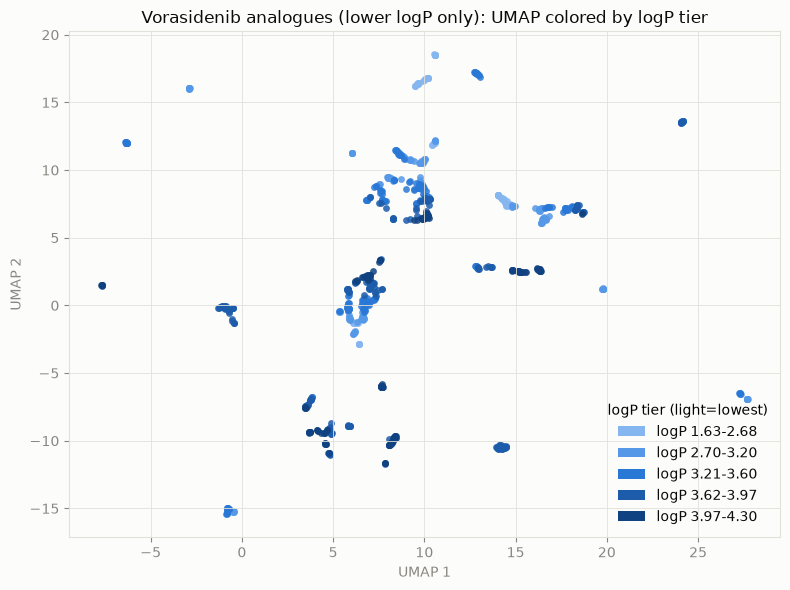

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Single-hue blue ordinal ramp, light->dark (validated: node scripts/validate_palette.js
# with --ordinal, all checks pass), one step per logP tier, lightest = lowest logP.
CLUSTER_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

legend_handles = []
for cluster_id in range(N_CLUSTERS):
    subset = df[df["logp_cluster"] == cluster_id]
    color = CLUSTER_COLORS[cluster_id]
    ax.scatter(subset["umap_1"], subset["umap_2"], s=24, color=color, linewidths=0, alpha=0.85)
    legend_handles.append(
        Patch(facecolor=color, label=f"logP {subset['logp'].min():.2f}-{subset['logp'].max():.2f}")
    )

ax.set_title("Vorasidenib analogues (lower logP only): UMAP colored by logP tier", color=INK, fontsize=12)
ax.set_xlabel("UMAP 1", color=MUTED)
ax.set_ylabel("UMAP 2", color=MUTED)
ax.tick_params(colors=MUTED)
for spine in ax.spines.values():
    spine.set_color(GRID)
ax.grid(color=GRID, linewidth=0.6)
ax.legend(handles=legend_handles, title="logP tier (light=lowest)", frameon=False, labelcolor=INK)
fig.tight_layout()
plt.show()